# Did The Sequence Extraction Work as Intended ??

In [7]:
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
BASE_DIR = "/nfs/scratch/pdb_dimers"

seqs_df = pd.read_csv(os.path.join(BASE_DIR, "entity_sequences.tsv"), sep="\t")

seqs_df.head()

,entity_name,cluster_id,sequence
0,7NW1_2,20365_100,MEKVTKDDFESLDVLGKGXFAYVVLVRRIGTNEYYAMKVVNKQGLL...
1,1OTR_2,10595_100,LGVDPSLQIDVLTELELGESTTGVRQVPGLHNGTKAFLFQDTPRSI...
2,3TCV_1,17036_100,SLDQSTVLSSCLTSCVTNLGRQLDSGTRYNLSEACIHGCQFWNSVD...
3,1PIY_1,65438_100,MEKVTKEDFETIDTLGKGXFAYVVLVRRVGTNNLYAMKVVNKQGLL...
4,4C6N_1,65438_100,MEKVTKEDFETIDTLGKGSFAYVVLVRRVGTNNLYAMKVVNKQGLL...


### Duplicate IDs ??

In [5]:
mask = seqs_df["entity_name"].duplicated()
seqs_df[mask]

,entity_name,cluster_id,sequence


### Length Of The Sequences

In [6]:
seqs_df["length"] = seqs_df["sequence"].str.len()
seqs_df["length"].describe()

count    52254.000000
mean       252.380047
std        243.883688
min          1.000000
25%        113.000000
50%        216.000000
75%        335.000000
max       5247.000000
Name: length, dtype: float64

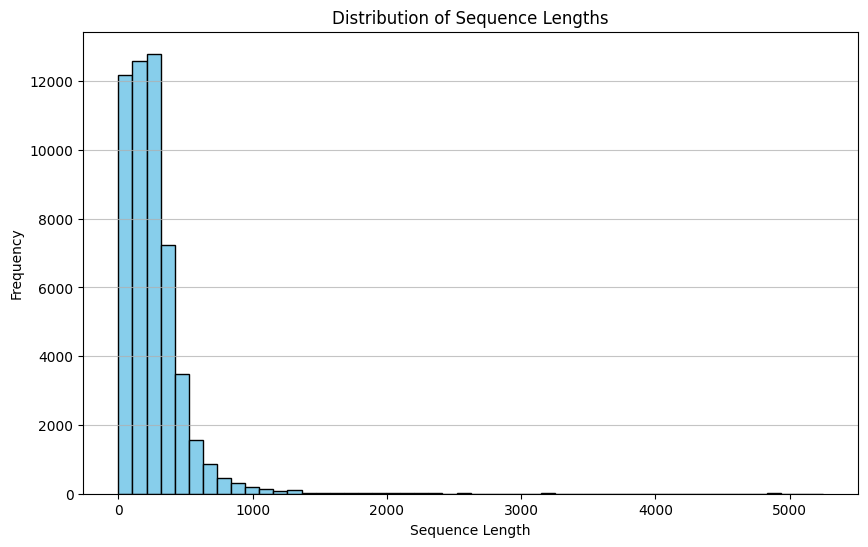

In [8]:
# Now a plot showing the distribution of sequence lengths
plt.figure(figsize=(10, 6))
plt.hist(seqs_df["length"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()

In [ ]:
# how many sequences are longer than 1500 residues?
print(f"Number of sequences longer than 1500 residues: {(seqs_df['length'] > 1500).sum()}")

Number of sequences longer than 1500 residues: 172


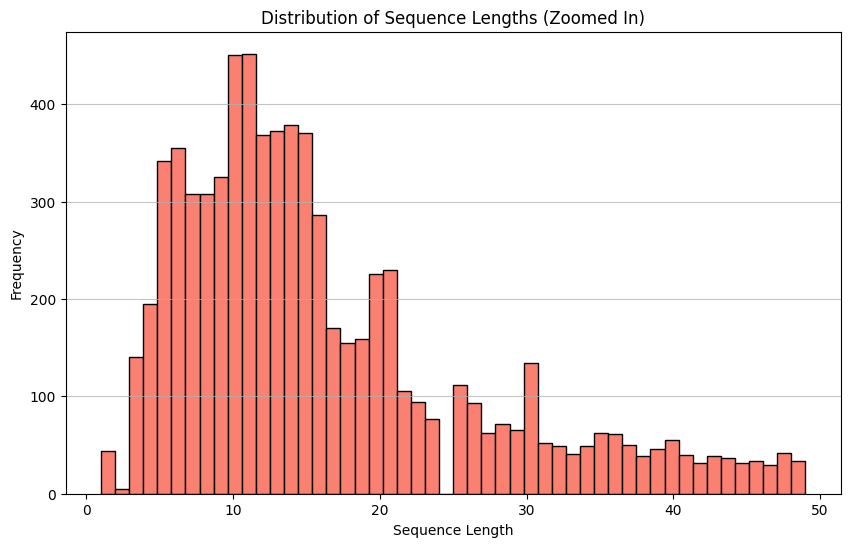

In [13]:
seqs_df_small = seqs_df[seqs_df["length"] < 50]
plt.figure(figsize=(10, 6))
plt.hist(seqs_df_small["length"], bins=50, color="salmon", edgecolor="black")
plt.title("Distribution of Sequence Lengths (Zoomed In)")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()